<small>This code was made by [Riccardo Campi](https://scholar.google.com/citations?user=JWSoz7EAAAAJ&hl=it), Politecnico di Milano, Data Science Lab.</small>
<br><small>Thanks to [UBC Library Research Computing](https://github.com/ubc-library-rc/ml-classification-clustering/) for inspiring this notebook.</small>

## Library Imports and CSV Loading

We import the necessary libraries for data analysis and visualization, then load the `california housing dataset` dataset from a CSV file.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import sklearn

## 5 Model

There are two types of tasks:
- **Supervised Learning**: The model is trained on a labeled dataset, which means that each training example is paired with an output label.
  <br>The goal is to learn a mapping from inputs to outputs, allowing the model to make predictions on new, unseen data.
  <br>Within supervised learning, there are two main types of problems:
  - **Classification**: The output variable is categorical, and the model predicts the class label for each input.
  - **Regression**: The output variable is continuous, and the model predicts a real-valued number for each input.
- **Unsupervised Learning**: The model is trained on an unlabeled dataset, which means that the training data does not have any output labels.
  <br>The goal is to find hidden patterns or intrinsic structures in the input data, such as clustering or dimensionality reduction.
  <br>Within unsupervised learning, there is one main type of problem:
  - **Clustering**: The model groups similar data points together based on their features, without any predefined labels.

### 5.1 Classification

In this section, we will focus on supervised learning, specifically classification, where the goal is to predict a categorical output variable based on input features.
<br>We will use the `iris dataset`, which contains information about various features of iris flowers and their corresponding species.

In [2]:
# IRIS dataset is a commonly used dataset in data analysis,
# which contains information about different species of iris flowers.
iris = pd.read_csv("./datasets/iris_seaborn.csv")

# Print the first few rows of the dataset
iris.head() 

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


#### 5.1.1 Visualization

We can use visualizations to understand the relationships between the features and the target variable `species`.
<br>For example, we can create scatter plots to visualize how different features relate to each other and to the species.

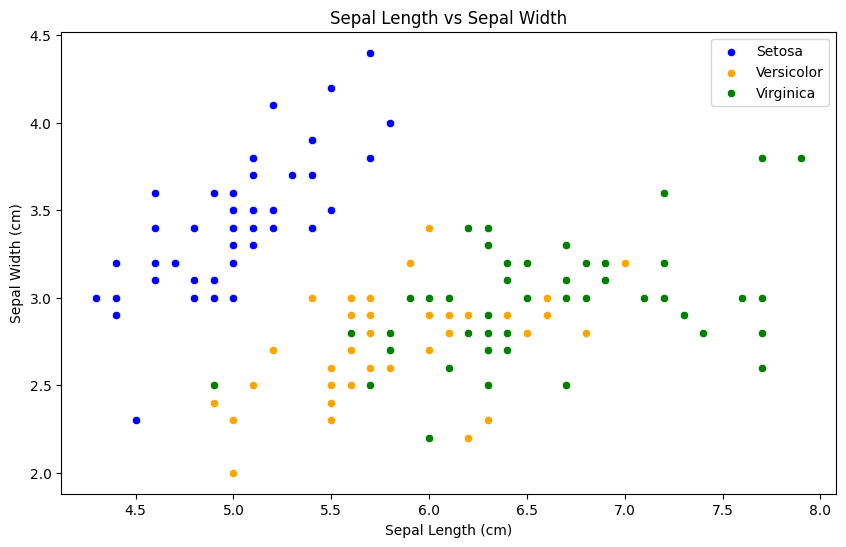

In [4]:
# Separe by target value
setosa = iris[iris.species == "setosa"]
versicolor = iris[iris.species=='versicolor']
virginica = iris[iris.species=='virginica']

# Create a scatter plot of sepal length vs sepal width
plt.figure(figsize=(10, 6))
sns.scatterplot(data=setosa, x='sepal_length', y='sepal_width', label='Setosa', color='blue')
sns.scatterplot(data=versicolor, x='sepal_length', y='sepal_width', label='Versicolor', color='orange')
sns.scatterplot(data=virginica, x='sepal_length', y='sepal_width', label='Virginica', color='green')
plt.title('Sepal Length vs Sepal Width')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.legend()
plt.show()

#### 5.1.2 Outliers

Outliers are data points that differ significantly from other observations in the dataset.
<br>Outliers can have a significant impact on the performance of machine learning models, as they can skew the results and lead to inaccurate predictions.
<br>In this example, we will check for outliers in the dataset using box plots.
<br>If we find any outliers, we will cap (winsorize) them to a certain threshold to reduce their impact on the model.

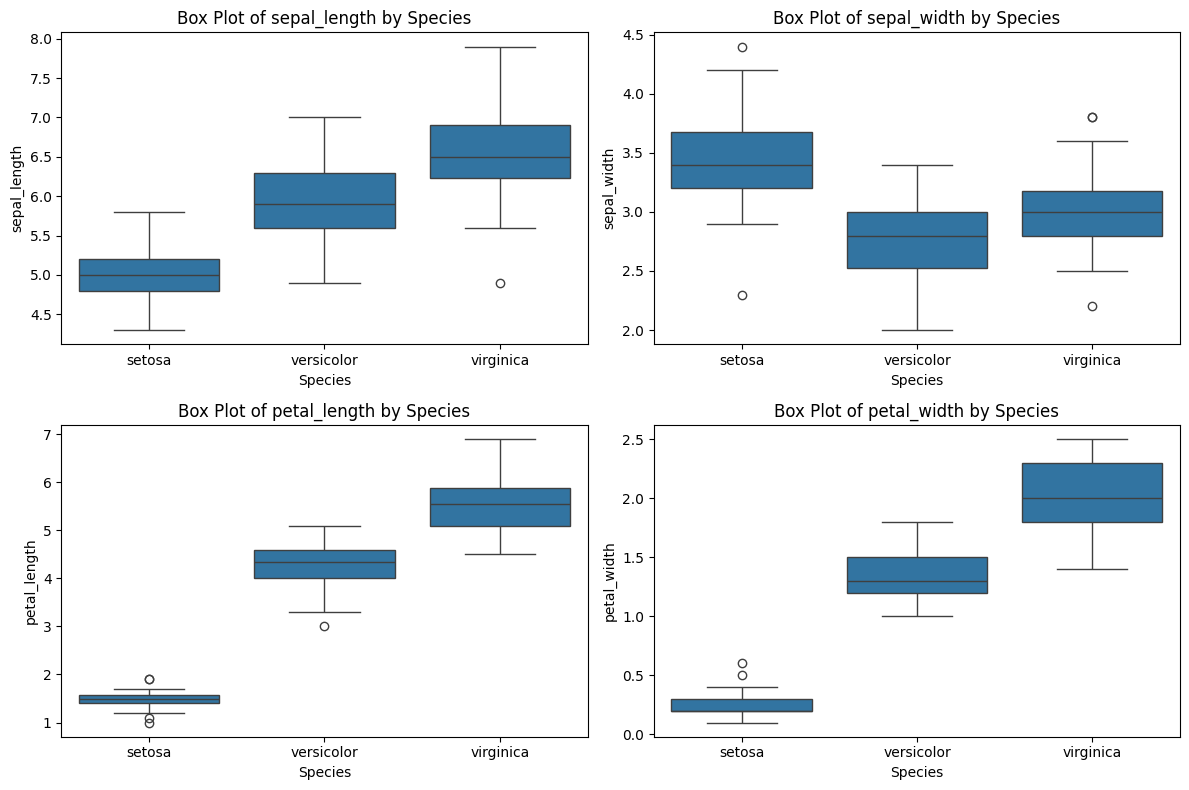

In [5]:
# Create box plots for each feature by species
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
plt.figure(figsize=(12, 8))
for i, feature in enumerate(features):
    plt.subplot(2, 2, i+1)
    sns.boxplot(x='species', y=feature, data=iris)
    plt.title(f'Box Plot of {feature} by Species')
    plt.xlabel('Species')
    plt.ylabel(feature)
plt.tight_layout()
plt.show()

# Cap the outliers in the original dataset using a 10% winsorization (95th and 5th percentiles)
iris_winsorized = iris.copy()
iris_winsorized['sepal_length'] = iris_winsorized['sepal_length'].clip(lower=iris_winsorized['sepal_length'].quantile(0.05), upper=iris_winsorized['sepal_length'].quantile(0.95))
iris_winsorized['sepal_width'] = iris_winsorized['sepal_width'].clip(lower=iris_winsorized['sepal_width'].quantile(0.05), upper=iris_winsorized['sepal_width'].quantile(0.95))
iris_winsorized['petal_length'] = iris_winsorized['petal_length'].clip(lower=iris_winsorized['petal_length'].quantile(0.05), upper=iris_winsorized['petal_length'].quantile(0.95))
iris_winsorized['petal_width'] = iris_winsorized['petal_width'].clip(lower=iris_winsorized['petal_width'].quantile(0.05), upper=iris_winsorized['petal_width'].quantile(0.95))

#### 5.1.3 Train/Test Split

Before training a model, we need to split our dataset into a training set and a test set.
<br>The training set is used to train the model, while the test set is used to evaluate its performance on unseen data.
<br>We can use the `train_test_split` function from the `sklearn.model_selection` module to perform this split.
<br>In this example, we will use 80% of the data for training and 20% for testing, and we will set a random state for reproducibility.

In [6]:
# Store the features and target variable in separate variables
X = iris_winsorized.drop('species', axis=1)  # Features
y = iris_winsorized['species']  # Target variable

# Train/test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### 5.1.4 Missing Values

In real-world datasets, it is common to encounter missing values.
<br>Before training a model, we need to handle these missing values appropriately, as they can affect the performance of the model.
<br>In this example, the dataset does not contain any missing values, but we will leave the code for handling missing values in case we need it in the future.
<br>We can use the `SimpleImputer` from the `sklearn.impute` module to fill in missing values with a specified strategy, such as the mean.

In [7]:
from sklearn.impute import SimpleImputer

# Initialize the SimpleImputer with a strategy (e.g., mean)
imputer = SimpleImputer(strategy='mean')

# Fit the imputer on the training data and transform both the training and test data
imputer.fit(X_train)
X_train_imputed = imputer.transform(X_train)
X_test_imputed = imputer.transform(X_test)

#### 5.1.5 Scaling

Before training a model, it is often beneficial to scale the features to ensure that they are on the same scale.
<br>Features with a higher value range start dominating the model's decision-making process, and the model may not learn from the features with a smaller value range.
<br>We can use the `StandardScaler` from the `sklearn.preprocessing` module to standardize the features by removing the mean and scaling to unit variance.

> Is important to fit the scaler only on the training data and then transform both the training and test data to avoid data leakage.

In [8]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both the training and test data
scaler.fit(X_train_imputed)
X_train_scaled = scaler.transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

#### 5.1.6 Feature Selection

Feature selection is the process of selecting a subset of relevant features for use in model construction.
<br>It can help improve the performance of the model by reducing overfitting, improving accuracy, and reducing training time.
<br>In this example, we will reduce the number of features to the two most important ones (sepal length and sepal width) for visualization purposes.

In [9]:
# Keep only the first two features
X_train_selection = X_train_scaled[:, :2]
X_test_selection = X_test_scaled[:, :2]

#### 5.1.7 Model Training (Logistic Regression Classifier)

After splitting the data, we can train a classification model using the training set.
<br>For example, we can use a `Logistic Regression Classifier` from the `sklearn.linear_model` module to train our model on the training data.

In [10]:
from sklearn.linear_model import LogisticRegression

# Create an instance of Logistic Regression Classifier and fit the data.
logreg = LogisticRegression(C=1e5)
logreg.fit(X_train_selection, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",100000.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term

In [11]:
logreg_pred = logreg.predict(X_test_selection)
print("Predictions:", logreg_pred)

Predictions: ['versicolor' 'setosa' 'virginica' 'versicolor' 'virginica' 'setosa'
 'versicolor' 'virginica' 'versicolor' 'versicolor' 'virginica' 'setosa'
 'setosa' 'setosa' 'setosa' 'virginica' 'virginica' 'versicolor'
 'versicolor' 'virginica' 'setosa' 'versicolor' 'setosa' 'virginica'
 'virginica' 'virginica' 'virginica' 'virginica' 'setosa' 'setosa']


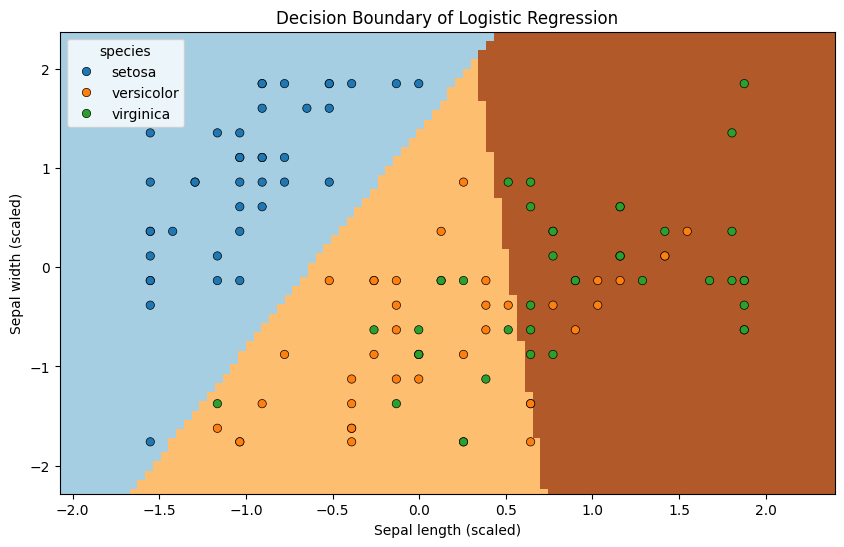

In [12]:
from sklearn.inspection import DecisionBoundaryDisplay

# Plot a decision boundary for the logistic regression model using the first two features (sepal length and sepal width)
plt.figure(figsize=(10, 6))
ax = plt.gca()
DecisionBoundaryDisplay.from_estimator(
    logreg,
    X_train_selection,
    cmap=plt.cm.Paired,
    ax=ax,
    response_method="predict",
    plot_method="pcolormesh",
    shading="auto",
    xlabel="Sepal length (scaled)",
    ylabel="Sepal width (scaled)",
    eps=0.5,
)
sns.scatterplot(x=X_train_selection[:, 0], y=X_train_selection[:, 1], hue=y_train, edgecolor='k', ax=ax)
plt.title('Decision Boundary of Logistic Regression')
plt.show()

> Note: to visualize the unscaled decision boundary, we need to create a pipeline that includes both the scaler and the classifier, and then use this pipeline to plot the decision boundary.

> The pipeline can also include the missing value imputation step and the feature selection step if needed, ensuring that all preprocessing steps are applied consistently during both training and prediction.

#### 5.1.8 Model Evaluation

After training the model, we need to evaluate its performance on the test set.
<br>We can use various metrics such as accuracy, precision, recall, and F1-score to assess how well the model is performing:
- **Accuracy**: The proportion of correct predictions out of the total number of predictions.
- **Precision**: The proportion of true positive predictions out of the total number of positive predictions.
- **Recall**: The proportion of true positive predictions out of the total number of actual positives.
- **F1-score**: The harmonic mean of precision and recall, providing a single metric that balances both precision and recall.

We can use the `classification_report` from the `sklearn.metrics` module to get a detailed report of the model's performance on the test set.

In [13]:
from sklearn.metrics import classification_report

# Print the accuracy, precision, recall, and F1-score of the model on the test set
print(classification_report(y_test, logreg_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.88      0.78      0.82         9
   virginica       0.83      0.91      0.87        11

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



A **confusion matrix** can also be used to visualize the performance of the classification model, showing the true positives, true negatives, false positives, and false negatives.

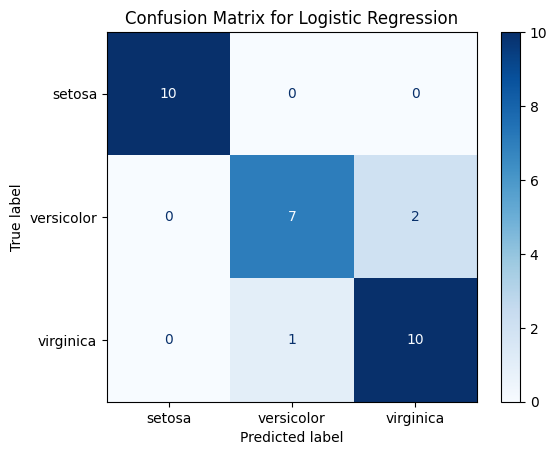

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Plot a confusion matrix to visualize the performance of the classification model
cm = confusion_matrix(y_test, logreg_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=logreg.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

#### 5.1.9 Classification with a Different Model (Decision Tree)

After evaluating the logistic regression model, we can also try training a different classification model, such as a `Decision Tree Classifier` from the `sklearn.tree` module.
<br>We can train the decision tree model on the same training data and evaluate its performance using the same metrics as before to compare the results with the logistic regression model.

In [15]:
from sklearn.tree import DecisionTreeClassifier

# Train a Decision Tree Classifier on the same training data
tree_clf = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf.fit(X_train_selection, y_train)

# Evaluate the Decision Tree Classifier on the test set
tree_pred = tree_clf.predict(X_test_selection)

# Print the classification report for the Decision Tree Classifier
print(classification_report(y_test, tree_pred))

              precision    recall  f1-score   support

      setosa       1.00      0.90      0.95        10
  versicolor       0.75      0.67      0.71         9
   virginica       0.77      0.91      0.83        11

    accuracy                           0.83        30
   macro avg       0.84      0.83      0.83        30
weighted avg       0.84      0.83      0.83        30



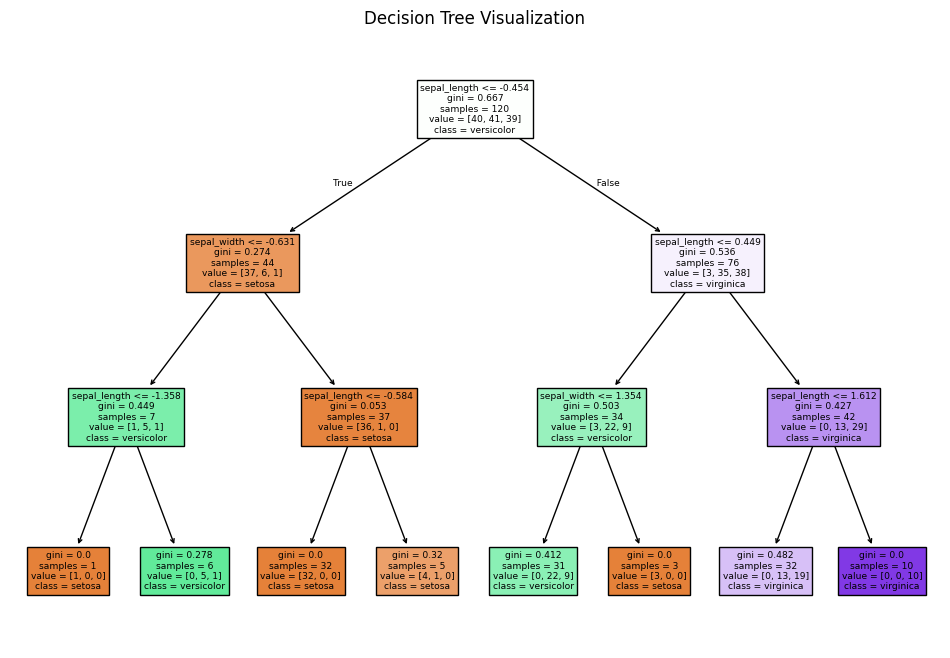

In [16]:
# Plot the decision tree itself (compact)
from sklearn.tree import plot_tree
plt.figure(figsize=(12, 8))
plot_tree(tree_clf, filled=True, feature_names=X.columns[:2], class_names=logreg.classes_)
plt.title('Decision Tree Visualization')
plt.show()

> The decision tree visualization can also be helpful to understand how the model is making decisions based on the features, and to identify which features are most important for the classification task.